In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\UJJWAL\Downloads")

In [31]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [73]:
df=pd.read_csv('ADANIPORTS.csv')

In [74]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [75]:
df.isnull().sum()

Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                866
Deliverable Volume      0
%Deliverble             0
dtype: int64

In [76]:
df.drop(columns='Trades',inplace=True,axis=1)

In [77]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,816123,0.2741


In [8]:
df.tail()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
3317,2021-04-26,ADANIPORTS,EQ,725.35,733.0,739.65,728.90,729.2,730.75,733.25,9390549,6.885658e+14,838079,0.0892
3318,2021-04-27,ADANIPORTS,EQ,730.75,735.0,757.50,727.35,748.6,749.15,747.67,20573107,1.538191e+15,1779639,0.0865
3319,2021-04-28,ADANIPORTS,EQ,749.15,755.0,760.00,741.10,743.4,746.25,751.02,11156977,8.379106e+14,1342353,0.1203
3320,2021-04-29,ADANIPORTS,EQ,746.25,753.2,765.85,743.40,746.4,746.75,753.06,13851910,1.043139e+15,1304895,0.0942
3321,2021-04-30,ADANIPORTS,EQ,746.75,739.0,759.45,724.50,726.4,730.05,743.35,12600934,9.366911e+14,3514692,0.2789


In [78]:
df.shape

(3322, 14)

In [79]:
df['Date']=pd.to_datetime(df['Date'])

In [80]:
df.set_index('Date',inplace=True)

In [81]:
df.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,
2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,9859619,0.3612
2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,1453278,0.3172
2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,1069678,0.2088
2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,1260913,0.2735
2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,816123,0.2741


<AxesSubplot:xlabel='Date'>

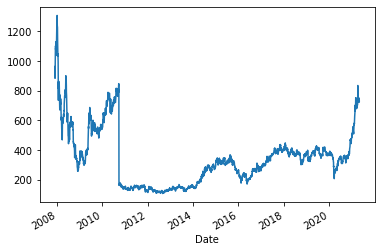

In [82]:
df['Close'].plot()

In [22]:
df1.head(40)

,Close
Date,
2007-11-27,962.90
2007-11-28,893.90
2007-11-29,884.20
2007-11-30,921.55
2007-12-03,969.30
2007-12-04,1041.45
2007-12-05,1082.45
2007-12-06,1081.30
2007-12-07,1102.40


In [83]:
from statsmodels.tsa.stattools import adfuller

In [84]:
def adfuller_test(close):
    result=adfuller(close)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [85]:
adfuller_test(df['Close'])

ADF Test Statistic : -3.473097683133425
p-value : 0.008705487700678952
#Lags Used : 5
Number of Observations Used : 3316
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [86]:
df.isnull().sum()

Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Deliverable Volume    0
%Deliverble           0
dtype: int64

In [87]:
from pmdarima import auto_arima

In [88]:
import warnings
warnings.filterwarnings('ignore')

In [89]:
stepwise_fit = auto_arima(df['Close'],trace=True,suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=28091.255, Time=3.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=28090.898, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=28087.660, Time=0.66 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=28087.758, Time=0.64 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=28088.958, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=28089.370, Time=0.94 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=28089.336, Time=1.90 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=28091.309, Time=6.00 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=28085.716, Time=0.30 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=28087.424, Time=0.92 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=28087.392, Time=0.99 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=28085.814, Time=0.27 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=28089.364, Time=1.16 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 17.687 seconds


In [90]:
stepwise_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3322
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -14040.858
Date:                Tue, 16 Aug 2022   AIC                          28085.716
Time:                        21:53:26   BIC                          28097.932
Sample:                             0   HQIC                         28090.088
                               - 3322                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0398      0.010      4.143      0.000       0.021       0.059
sigma2       275.3166      0.339    812.322      0.000     274.652     275.981
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):          91234346.23
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.12   Skew:                           -19.84
Prob(H) (two-sided):                  0.00   Kurtosis:                       814.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [91]:
from statsmodels.tsa.arima_model import ARIMA

In [98]:
train=df.iloc[:-100]
test=df.iloc[-100:]

In [99]:
df.shape

(3322, 13)

In [100]:
train.shape
# test.shape

(3222, 13)

In [101]:
test.shape

(100, 13)

In [97]:
model = ARIMA(df['Close'],order=(1,1,0))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:                D.Close   No. Observations:                 3321
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -14040.827
Method:                       css-mle   S.D. of innovations             16.593
Date:                Tue, 16 Aug 2022   AIC                          28087.655
Time:                        21:59:27   BIC                          28105.979
Sample:                             1   HQIC                         28094.212
                                                                              
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0712      0.300     -0.237      0.812      -0.659       0.517
ar.L1.D.Close     0.0398      0.017      2.291      0.022       0.006       0.074
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1           25.1104           +0.0000j           25.1104            0.0000
-----------------------------------------------------------------------------
"""

In [102]:
start = len(train)
end = len(train)+len(test)-1
pred=model.predict(start=start,end=end,typ='levels')
pred.index=df.index[start:end+1]
print(pred)

Date
2020-12-03    438.705110
2020-12-04    435.636063
2020-12-07    454.344495
2020-12-08    472.140512
2020-12-09    462.957074
                 ...    
2021-04-26    724.785830
2021-04-27    730.896692
2021-04-28    749.814407
2021-04-29    746.066151
2021-04-30    746.701554
Length: 100, dtype: float64


In [103]:
test.tail()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,
2021-04-26,ADANIPORTS,EQ,725.35,733.0,739.65,728.90,729.2,730.75,733.25,9390549,6.885658e+14,838079,0.0892
2021-04-27,ADANIPORTS,EQ,730.75,735.0,757.50,727.35,748.6,749.15,747.67,20573107,1.538191e+15,1779639,0.0865
2021-04-28,ADANIPORTS,EQ,749.15,755.0,760.00,741.10,743.4,746.25,751.02,11156977,8.379106e+14,1342353,0.1203
2021-04-29,ADANIPORTS,EQ,746.25,753.2,765.85,743.40,746.4,746.75,753.06,13851910,1.043139e+15,1304895,0.0942
2021-04-30,ADANIPORTS,EQ,746.75,739.0,759.45,724.50,726.4,730.05,743.35,12600934,9.366911e+14,3514692,0.2789


<AxesSubplot:xlabel='Date'>

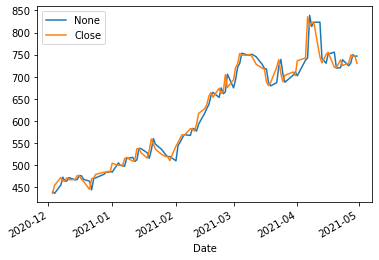

In [104]:
pred.plot(legend=True)
test['Close'].plot(legend=True)

In [106]:
test['Close'].mean()

615.868

In [107]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(pred,test['Close']))
print(rmse)

19.268117314881607


In [108]:
model2 = ARIMA(df['Close'],order=(1,1,0))
model2 = model2.fit()
df.tail()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,
2021-04-26,ADANIPORTS,EQ,725.35,733.0,739.65,728.90,729.2,730.75,733.25,9390549,6.885658e+14,838079,0.0892
2021-04-27,ADANIPORTS,EQ,730.75,735.0,757.50,727.35,748.6,749.15,747.67,20573107,1.538191e+15,1779639,0.0865
2021-04-28,ADANIPORTS,EQ,749.15,755.0,760.00,741.10,743.4,746.25,751.02,11156977,8.379106e+14,1342353,0.1203
2021-04-29,ADANIPORTS,EQ,746.25,753.2,765.85,743.40,746.4,746.75,753.06,13851910,1.043139e+15,1304895,0.0942
2021-04-30,ADANIPORTS,EQ,746.75,739.0,759.45,724.50,726.4,730.05,743.35,12600934,9.366911e+14,3514692,0.2789


In [130]:
index_future = pd.date_range(start='2021-04-30',end='2021-05-30')
pred = model2.predict(start=len(df),end=len(df)+30,typ='levels').rename('ARIMA Predictions')
pred.index= index_future
pred.shape

(31,)

In [131]:
pred.head(30)

2021-04-30    729.316577
2021-05-01    729.219011
2021-05-02    729.146767
2021-05-03    729.075532
2021-05-04    729.004336
2021-05-05    728.933143
2021-05-06    728.861949
2021-05-07    728.790755
2021-05-08    728.719562
2021-05-09    728.648368
2021-05-10    728.577174
2021-05-11    728.505981
2021-05-12    728.434787
2021-05-13    728.363593
2021-05-14    728.292400
2021-05-15    728.221206
2021-05-16    728.150012
2021-05-17    728.078819
2021-05-18    728.007625
2021-05-19    727.936431
2021-05-20    727.865238
2021-05-21    727.794044
2021-05-22    727.722850
2021-05-23    727.651657
2021-05-24    727.580463
2021-05-25    727.509269
2021-05-26    727.438076
2021-05-27    727.366882
2021-05-28    727.295688
2021-05-29    727.224495
Freq: D, Name: ARIMA Predictions, dtype: float64

<AxesSubplot:>

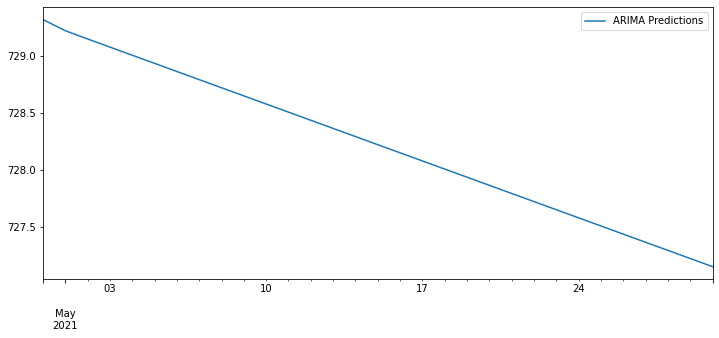

In [111]:
pred.plot(figsize=(12,5),legend=True)